In [2]:
import numpy as np
import pandas as pd

# 1. Load and inspect data 

In [183]:
df = pd.read_csv('../data/data_FraudDetection_JAR2020.csv')

In [184]:
df

,fyear,gvkey,p_aaer,misstate,act,ap,at,ceq,che,cogs,...,soft_assets,ch_cs,ch_cm,ch_roa,issue,bm,dpi,reoa,EBIT,ch_fcf
0,1990,1009,NaN,0,10.047,3.736,32.335,6.262,0.002,30.633,...,0.312,0.095,0.083,-0.020,1,0.413,0.874,0.168,0.162,-0.042
1,1990,1011,NaN,0,1.247,0.803,7.784,0.667,0.171,1.125,...,0.316,0.189,-0.211,-0.118,1,0.158,0.745,-0.429,-0.158,0.100
2,1990,1017,NaN,0,55.040,3.601,118.120,44.393,3.132,107.343,...,0.605,0.098,-0.106,0.091,1,2.231,1.015,0.395,0.064,0.066
3,1990,1021,NaN,0,24.684,3.948,34.591,7.751,0.411,31.214,...,0.793,-0.006,-0.250,0.018,1,1.044,1.026,0.095,0.088,-0.017
4,1990,1028,NaN,0,17.325,3.520,27.542,-12.142,1.017,32.662,...,0.869,-0.232,-1.675,-0.467,0,-1.603,0.598,-0.942,-0.701,0.130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146040,2014,314866,NaN,0,262.600,12.400,"1,234.800",194.100,166.200,214.400,...,0.752,0.560,0.127,-0.051,1,0.104,0.830,-0.327,-0.008,-0.262
146041,2014,315318,NaN,0,"1,578.400",106.700,"4,557.600","2,459.600",997.300,324.400,...,0.743,-0.118,0.031,0.095,1,0.582,0.743,-0.078,0.000,-0.297
146042,2014,316056,NaN,0,973.800,249.500,"2,015.900",-4.800,290.500,"1,185.500",...,0.751,0.004,-0.038,0.072,1,-0.001,1.064,-0.003,0.153,0.066
146043,2014,317260,NaN,0,51.743,1.555,322.421,319.230,46.398,24.319,...,0.018,NaN,NaN,NaN,1,1.109,NaN,0.000,0.029,NaN


# Accounting Fraud Detection Dataset — Feature Dictionary

This dataset contains **146,045 firm-year observations and 46 variables** from publicly traded U.S. firms. The data were used in Yang Bao, Bin Ke, Bin Li, Julia Yu, and Jie Zhang (2020), *Detecting Accounting Fraud in Publicly Traded U.S. Firms Using a Machine Learning Approach*, published in the *Journal of Accounting Research*. The dataset combines accounting variables, derived financial features, the fraud label, and variables used for identification or fraud-history handling.

## 1. Target / Label

### `misstate` — Accounting Misstatement / Fraud Label

The **target variable** that our machine-learning model will predict.

* `0` = Non-fraudulent / no identified misstatement
* `1` = Fraudulent / misstatement observation

In machine learning terminology, `misstate` is the **target**, **label**, or **dependent variable**.

It is **not used as an input feature** because it is the answer that the model is trying to learn to predict.

---

# 2. Identification and Related Variables

### `fyear` — Fiscal Year

The fiscal year associated with the firm's financial observation.

It tells us **when** the observation occurred. We will use it primarily for temporal analysis and time-based training/validation/testing rather than automatically treating it as a predictive financial feature.

### `gvkey` — Global Company Key

A unique identifier assigned to a company in the Compustat database.

It identifies **which company** the observation belongs to. It is useful for grouping firms and investigating repeated firm-year observations, but it should not normally be given directly to the model as an ordinary financial predictor.

### `p_aaer` — Prior AAER / Prior Fraud-Related Indicator

A variable associated with the handling of **serial fraud observations** in the original study.

AAER means **Accounting and Auditing Enforcement Release**, referring to enforcement releases associated with accounting and auditing violations.

Because `p_aaer` is related to prior fraud information and is extremely sparse in this dataset, we must perform a specific **leakage and availability analysis** before deciding whether it can legitimately be used as a predictive feature.

---

# 3. Raw Accounting Variables

These 28 variables represent accounting and financial-statement information used in the original dataset.

### `act` — Current Assets, Total

The firm's total current assets, such as cash, receivables, and inventory.

### `ap` — Accounts Payable, Trade

Amounts owed by the company to suppliers for goods and services purchased on credit.

### `at` — Assets, Total

The firm's total assets.

This represents the total economic resources reported by the company.

### `ceq` — Common/Ordinary Equity, Total

The total common shareholders' equity attributable to ordinary shareholders.

### `che` — Cash and Short-Term Investments

Cash, cash equivalents, and short-term investments held by the company.

### `cogs` — Cost of Goods Sold

The cost directly associated with producing or acquiring the goods or services sold by the company.

### `csho` — Common Shares Outstanding

The number of common shares outstanding.

### `dlc` — Debt in Current Liabilities, Total

Debt obligations classified as current liabilities, generally amounts due within the short term.

### `dltis` — Long-Term Debt Issuance

Long-term debt issued by the company during the relevant period.

### `dltt` — Long-Term Debt, Total

The company's total long-term debt obligations.

### `dp` — Depreciation and Amortization

Depreciation and amortization expense associated with the use or consumption of long-term assets and intangible assets.

### `ib` — Income Before Extraordinary Items

Income before extraordinary items.

It represents earnings before extraordinary items are considered.

### `invt` — Inventories, Total

The total value of inventory held by the company.

### `ivao` — Investment and Advances, Other

Other investments and advances that are not classified as short-term investments.

### `ivst` — Short-Term Investments, Total

Investments that are classified as short-term.

### `lct` — Current Liabilities, Total

The company's total current liabilities, generally obligations expected to be settled in the short term.

### `lt` — Liabilities, Total

The company's total liabilities.

### `ni` — Net Income / Loss

The company's reported net income or net loss.

This represents the profit or loss after applicable expenses and taxes.

### `ppegt` — Property, Plant and Equipment, Total

The total reported value of property, plant, and equipment.

These are long-term tangible operating assets such as buildings, machinery, and equipment.

### `pstk` — Preferred/Preference Stock, Total

The total value of preferred or preference stock capital.

### `re` — Retained Earnings

Cumulative earnings retained by the company rather than distributed to shareholders as dividends.

### `rect` — Receivables, Total

Amounts owed to the company by customers and other parties.

### `sale` — Sales / Turnover, Net

The company's net sales or operating revenue.

### `sstk` — Sale of Common and Preferred Stock

Proceeds or value associated with the issuance/sale of common and preferred shares.

### `txp` — Income Taxes Payable

Income tax obligations currently payable by the company.

### `txt` — Income Taxes, Total

The company's total reported income-tax expense or related income-tax amount.

### `xint` — Interest and Related Expense, Total

Interest expense and related financing costs.

### `prcc_f` — Price Close, Annual, Fiscal

The company's annual fiscal-year closing share price.

---

# 4. Derived Financial Features / Ratios

These variables are calculated or constructed from underlying accounting information. They attempt to capture financial relationships, changes, and patterns that may be informative for detecting accounting fraud.

### `dch_wc` — Change in Working-Capital Accruals

A measure related to changes in working-capital accruals.

It captures changes in accounting accruals associated with working capital.

### `ch_rsst` — Change in RSST Accruals

RSST refers to the **Richardson, Sloan, Soliman, and Tuna** accrual measure.

This feature captures changes in a broader measure of accruals and is designed to identify unusual accrual behaviour.

### `dch_rec` — Change in Receivables

Measures the change in the company's receivables relative to its financial activity.

Large or unusual increases in receivables can sometimes be associated with aggressive revenue recognition.

### `dch_inv` — Change in Inventory

Measures changes in inventory relative to the company's financial activity.

Unusual inventory movements may provide information about potential accounting irregularities.

### `soft_assets` — Percentage of Soft Assets

Measures the proportion of assets that are considered relatively "soft" or less directly tied to tangible operating assets.

Soft assets generally include items such as receivables and other less tangible/current assets.

### `ch_cs` — Change in Cash Sales

Measures the change in sales measured on a cash-related basis.

It helps capture changes between reported sales activity and cash-generating activity.

### `ch_cm` — Change in Cash Margin

Measures the change in the company's cash margin.

It captures changes in the relationship between cash-based operating performance and sales.

### `ch_roa` — Change in Return on Assets

Measures the change in **Return on Assets (ROA)**.

ROA relates profitability to the assets used to generate that profitability.

### `issue` — Actual Issuance

Indicates whether the company actually issued securities, such as shares.

In the dataset this is an indicator-type variable.

### `bm` — Book-to-Market Ratio

The relationship between the company's book value and its market value.

It compares accounting-based equity value with market-based valuation.

### `dpi` — Depreciation Index

An index measuring the change in depreciation relative to the company's property, plant, and equipment.

It can capture changes in depreciation behaviour or asset-age characteristics.

### `reoa` — Retained Earnings over Total Assets

Retained earnings divided by total assets.

It measures the proportion of the company's assets represented by accumulated retained earnings.

### `EBIT` — Earnings Before Interest and Taxes over Total Assets

A profitability measure based on **Earnings Before Interest and Taxes (EBIT)** relative to total assets.

It captures operating profitability relative to the company's asset base.

### `ch_fcf` — Change in Free Cash Flow

Measures the change in the company's free cash flow.

Free cash flow broadly represents cash generated by the business after considering relevant investment requirements.

---

# 5. How These Variables Will Be Used in Our Machine-Learning Project

The dataset therefore contains three important categories:

**Target:**

`misstate`

**Predictive features:**

* 28 raw accounting variables
* 14 derived financial features

**Identification / methodological variables:**

* `fyear`
* `gvkey`
* `p_aaer`

The initial modelling feature sets will therefore be:

### Feature Set A — Raw Accounting Variables

The 28 raw accounting variables only.

### Feature Set B — Derived Financial Features

The 14 derived financial features only.

### Feature Set C — Combined Features

The 28 raw accounting variables + 14 derived financial features.

The following will initially be excluded from ordinary predictive features:

* `misstate` — because it is the target
* `gvkey` — because it is a company identifier
* `fyear` — initially used for temporal validation rather than as an ordinary predictor
* `p_aaer` — pending a specific leakage and information-availability assessment

This approach allows us to determine whether **raw accounting information, derived financial ratios, or their combination** provides the strongest predictive performance.

### Important research principle

A feature being important to the model does **not** mean that it causes accounting fraud.

The model learns **predictive associations and patterns** between financial characteristics and the fraud label. These associations should not automatically be interpreted as causal relationships.


In [185]:
# Get all column names
print(df.columns.tolist())

df.columns

['fyear', 'gvkey', 'p_aaer', 'misstate', 'act', 'ap', 'at', 'ceq', 'che', 'cogs', 'csho', 'dlc', 'dltis', 'dltt', 'dp', 'ib', 'invt', 'ivao', 'ivst', 'lct', 'lt', 'ni', 'ppegt', 'pstk', 're', 'rect', 'sale', 'sstk', 'txp', 'txt', 'xint', 'prcc_f', 'dch_wc', 'ch_rsst', 'dch_rec', 'dch_inv', 'soft_assets', 'ch_cs', 'ch_cm', 'ch_roa', 'issue', 'bm', 'dpi', 'reoa', 'EBIT', 'ch_fcf']


Index(['fyear', 'gvkey', 'p_aaer', 'misstate', 'act', 'ap', 'at', 'ceq', 'che',
       'cogs', 'csho', 'dlc', 'dltis', 'dltt', 'dp', 'ib', 'invt', 'ivao',
       'ivst', 'lct', 'lt', 'ni', 'ppegt', 'pstk', 're', 'rect', 'sale',
       'sstk', 'txp', 'txt', 'xint', 'prcc_f', 'dch_wc', 'ch_rsst', 'dch_rec',
       'dch_inv', 'soft_assets', 'ch_cs', 'ch_cm', 'ch_roa', 'issue', 'bm',
       'dpi', 'reoa', 'EBIT', 'ch_fcf'],
      dtype='object')

In [186]:
# Display the data type of every column
df.dtypes

fyear            int64
gvkey            int64
p_aaer         float64
misstate         int64
act            float64
ap             float64
at             float64
ceq            float64
che            float64
cogs           float64
csho           float64
dlc            float64
dltis          float64
dltt           float64
dp             float64
ib             float64
invt           float64
ivao           float64
ivst           float64
lct            float64
lt             float64
ni             float64
ppegt          float64
pstk           float64
re             float64
rect           float64
sale           float64
sstk           float64
txp            float64
txt            float64
xint           float64
prcc_f         float64
dch_wc         float64
ch_rsst        float64
dch_rec        float64
dch_inv        float64
soft_assets    float64
ch_cs          float64
ch_cm          float64
ch_roa         float64
issue            int64
bm             float64
dpi            float64
reoa       

In [187]:
# Display a compact summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146045 entries, 0 to 146044
Data columns (total 46 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   fyear        146045 non-null  int64  
 1   gvkey        146045 non-null  int64  
 2   p_aaer       964 non-null     float64
 3   misstate     146045 non-null  int64  
 4   act          146045 non-null  float64
 5   ap           146045 non-null  float64
 6   at           146045 non-null  float64
 7   ceq          146045 non-null  float64
 8   che          146045 non-null  float64
 9   cogs         146045 non-null  float64
 10  csho         146045 non-null  float64
 11  dlc          146045 non-null  float64
 12  dltis        146045 non-null  float64
 13  dltt         146045 non-null  float64
 14  dp           146045 non-null  float64
 15  ib           146045 non-null  float64
 16  invt         146045 non-null  float64
 17  ivao         146045 non-null  float64
 18  ivst         146045 non-

In [188]:
# --- Cell 7: Identifier overview ---

print(f"Fiscal year range: {df['fyear'].min()} to {df['fyear'].max()}")
print(f"Number of unique fiscal years: {df['fyear'].nunique()}")
print(f"Number of unique companies (gvkey): {df['gvkey'].nunique()}")

obs_per_company = df.groupby("gvkey").size()   # how many firm-year rows each company contributes
print("\nObservations per company — summary statistics:")
print(obs_per_company.describe())

Fiscal year range: 1990 to 2014
Number of unique fiscal years: 25
Number of unique companies (gvkey): 18444

Observations per company — summary statistics:
count   18,444.000
mean         7.918
std          6.376
min          1.000
25%          3.000
50%          6.000
75%         11.000
max         25.000
dtype: float64


In [189]:
# --- Cell 8: Descriptive statistics ---

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")  # cleaner number formatting
df.describe().T   # .T (transpose) so variables are rows, easier to read for 46 columns

,count,mean,std,min,25%,50%,75%,max
fyear,"146,045.000","2,002.012",6.960,"1,990.000","1,996.000","2,002.000","2,008.000","2,014.000"
gvkey,"146,045.000","54,243.436","59,937.456","1,004.000","10,658.000","25,088.000","66,586.000","317,264.000"
p_aaer,964.000,"2,503.840",912.093,371.000,"1,803.000","2,620.500","3,180.000","3,996.000"
misstate,"146,045.000",0.007,0.081,0.000,0.000,0.000,0.000,1.000
act,"146,045.000",737.848,"3,744.542",-0.254,8.277,47.501,249.832,"152,629.000"
ap,"146,045.000",181.993,"1,047.546",0.000,1.151,6.462,42.259,"39,903.000"
at,"146,045.000","2,374.042","11,957.737",0.000,18.281,105.346,672.929,"410,074.000"
ceq,"146,045.000",887.126,"5,056.948","-25,560.000",6.337,47.308,271.547,"284,434.000"
che,"146,045.000",218.657,"1,330.490",-34.000,1.144,9.373,60.286,"85,709.000"
cogs,"146,045.000","1,302.281","7,870.666",-366.645,6.795,53.382,372.730,"435,726.253"


In [190]:
# --- Cell 10: Target distribution ---

target_counts = df["misstate"].value_counts()
target_pct = df["misstate"].value_counts(normalize=True) * 100

print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_pct.round(3))

Counts:
misstate
0    145081
1       964
Name: count, dtype: int64

Percentages:
misstate
0   99.340
1    0.660
Name: proportion, dtype: float64


In [191]:
# --- Cell 11: Fraud counts by year ---

fraud_by_year = df.groupby("fyear")["misstate"].agg(
    total_obs="count",
    fraud_obs="sum"
)
fraud_by_year["fraud_pct"] = (fraud_by_year["fraud_obs"] / fraud_by_year["total_obs"] * 100).round(3)

fraud_by_year

,total_obs,fraud_obs,fraud_pct
fyear,,,
1990,4582,15,0.327
1991,4713,27,0.573
1992,4970,26,0.523
1993,5377,30,0.558
1994,5684,23,0.405
1995,6230,22,0.353
1996,6745,33,0.489
1997,6789,42,0.619
1998,6716,56,0.834


# 2. Missing Data and Duplicates Audit

In [192]:
# Count missing values in every column
# missing values 
miss = df.isnull().sum()
missing_pct = miss * 100 / len(df)
report = pd.DataFrame({
    'missing_data': miss,
    'missing_pct': missing_pct
}).sort_values(by = 'missing_pct', ascending = False)
print(f'Missing data: \n {report[miss > 0]}\n')


Missing data: 
              missing_data  missing_pct
p_aaer             145081       99.340
ch_cm               17107       11.714
ch_cs               15918       10.899
ch_roa              12678        8.681
dpi                  9228        6.319
ch_fcf               5407        3.702
ch_rsst              4851        3.322
dch_wc               4759        3.259
dch_rec              4743        3.248
dch_inv              4615        3.160
soft_assets           592        0.405
reoa                  591        0.405
EBIT                  591        0.405
bm                     18        0.012



C:\Users\blaizo\AppData\Local\Temp\ipykernel_46752\166675184.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'Missing data: \n {report[miss > 0]}\n')


In [193]:
# Drop columns with >60% missing
df = df.drop(columns=['p_aaer', ], errors='ignore')

In [194]:
# 1. Fill categorical columns with Mode. But there are not cat_cols above

# 2. Fill numeric and date columns that have missing values with Median
num_cols = ['ch_cm', 'ch_cs', 'ch_roa', 'dpi', 'ch_fcf', 'ch_rsst', 'dch_wc', 'dch_rec', 'dch_inv', 'soft_assets', 'reoa', 'EBIT', 'bm']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
print('success')

success


In [195]:
# check missing values in every column again
# missing values 
miss = df.isnull().sum()
missing_pct = miss * 100 / len(df)
report = pd.DataFrame({
    'missing data': miss,
    'missing_pct': missing_pct
}).sort_values(by = 'missing_pct', ascending = False)
print(f'Missing data: \n {report[miss > 0]}\n')


Missing data: 
 Empty DataFrame
Columns: [missing data, missing_pct]
Index: []



C:\Users\blaizo\AppData\Local\Temp\ipykernel_46752\5762595.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'Missing data: \n {report[miss > 0]}\n')


In [196]:
#1 duplicate check
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


In [197]:
# Rename the target column from "misstate" to "target"
df = df.rename(columns={"misstate": "target"})

In [198]:
df.columns

Index(['fyear', 'gvkey', 'target', 'act', 'ap', 'at', 'ceq', 'che', 'cogs',
       'csho', 'dlc', 'dltis', 'dltt', 'dp', 'ib', 'invt', 'ivao', 'ivst',
       'lct', 'lt', 'ni', 'ppegt', 'pstk', 're', 'rect', 'sale', 'sstk', 'txp',
       'txt', 'xint', 'prcc_f', 'dch_wc', 'ch_rsst', 'dch_rec', 'dch_inv',
       'soft_assets', 'ch_cs', 'ch_cm', 'ch_roa', 'issue', 'bm', 'dpi', 'reoa',
       'EBIT', 'ch_fcf'],
      dtype='object')

# 3. EDA (Exploratory Data Analysis)

### 3.1 Univariate Analyses

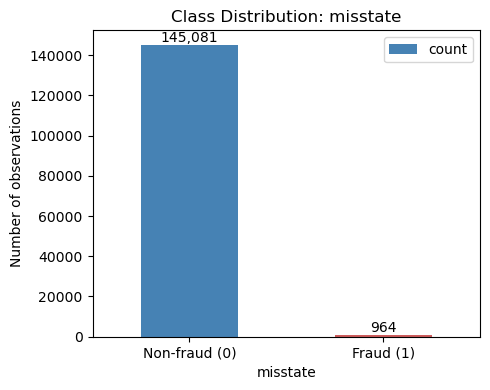

In [199]:
# --- Cell 12: Plot class distribution ---

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", ax=ax, color=["steelblue", "indianred"])
ax.set_xticklabels(["Non-fraud (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Number of observations")
ax.set_title("Class Distribution: misstate")

# Annotate bars with exact counts, since the imbalance makes the smaller bar hard to read
for i, v in enumerate(target_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.legend()
plt.show()

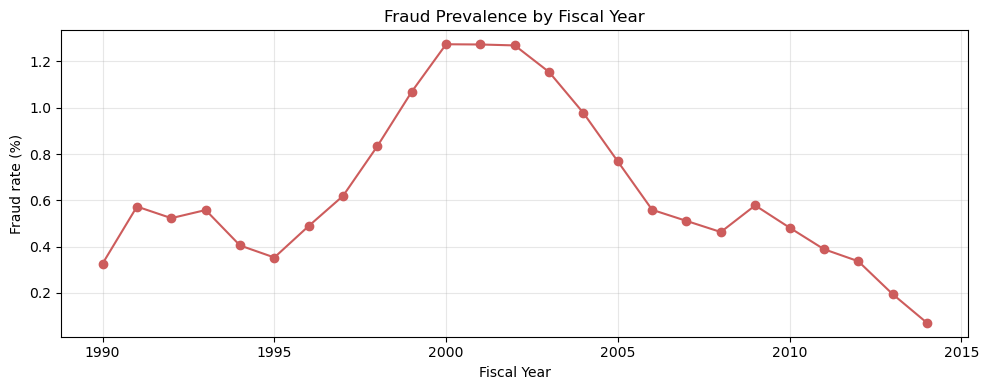

In [200]:
# --- Cell 13: Plot fraud rate by year ---

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fraud_by_year.index, fraud_by_year["fraud_pct"], marker="o", color="indianred")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud Prevalence by Fiscal Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [201]:
# Define feature groups based on the context
raw_accounting_vars = [
    'act', 'ap', 'at', 'ceq', 'che', 'cogs', 'csho', 'dlc', 'dltis', 'dltt',
    'dp', 'ib', 'invt', 'ivao', 'ivst', 'lct', 'lt', 'ni', 'ppegt', 'pstk',
    're', 'rect', 'sale', 'sstk', 'txp', 'txt', 'xint', 'prcc_f'
]

derived_features = [
    'dch_wc', 'ch_rsst', 'dch_rec', 'dch_inv', 'soft_assets', 'ch_cs', 
    'ch_cm', 'ch_roa', 'issue', 'bm', 'dpi', 'reoa', 'EBIT', 'ch_fcf'
]

# Exclude leakage-prone variables
exclude_vars = ['gvkey', 'fyear', 'p_aaer', 'target']

print(f"Raw accounting variables: {len(raw_accounting_vars)}")
print(f"Derived features: {len(derived_features)}")
print(f"Total model features: {len(raw_accounting_vars) + len(derived_features)}")

Raw accounting variables: 28
Derived features: 14
Total model features: 42


In [202]:

# Get all numeric columns (exclude leakage vars)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude = ['gvkey', 'fyear', 'p_aaer', 'target']
numeric_cols = [c for c in numeric_cols if c not in exclude]
len(numeric_cols)

42

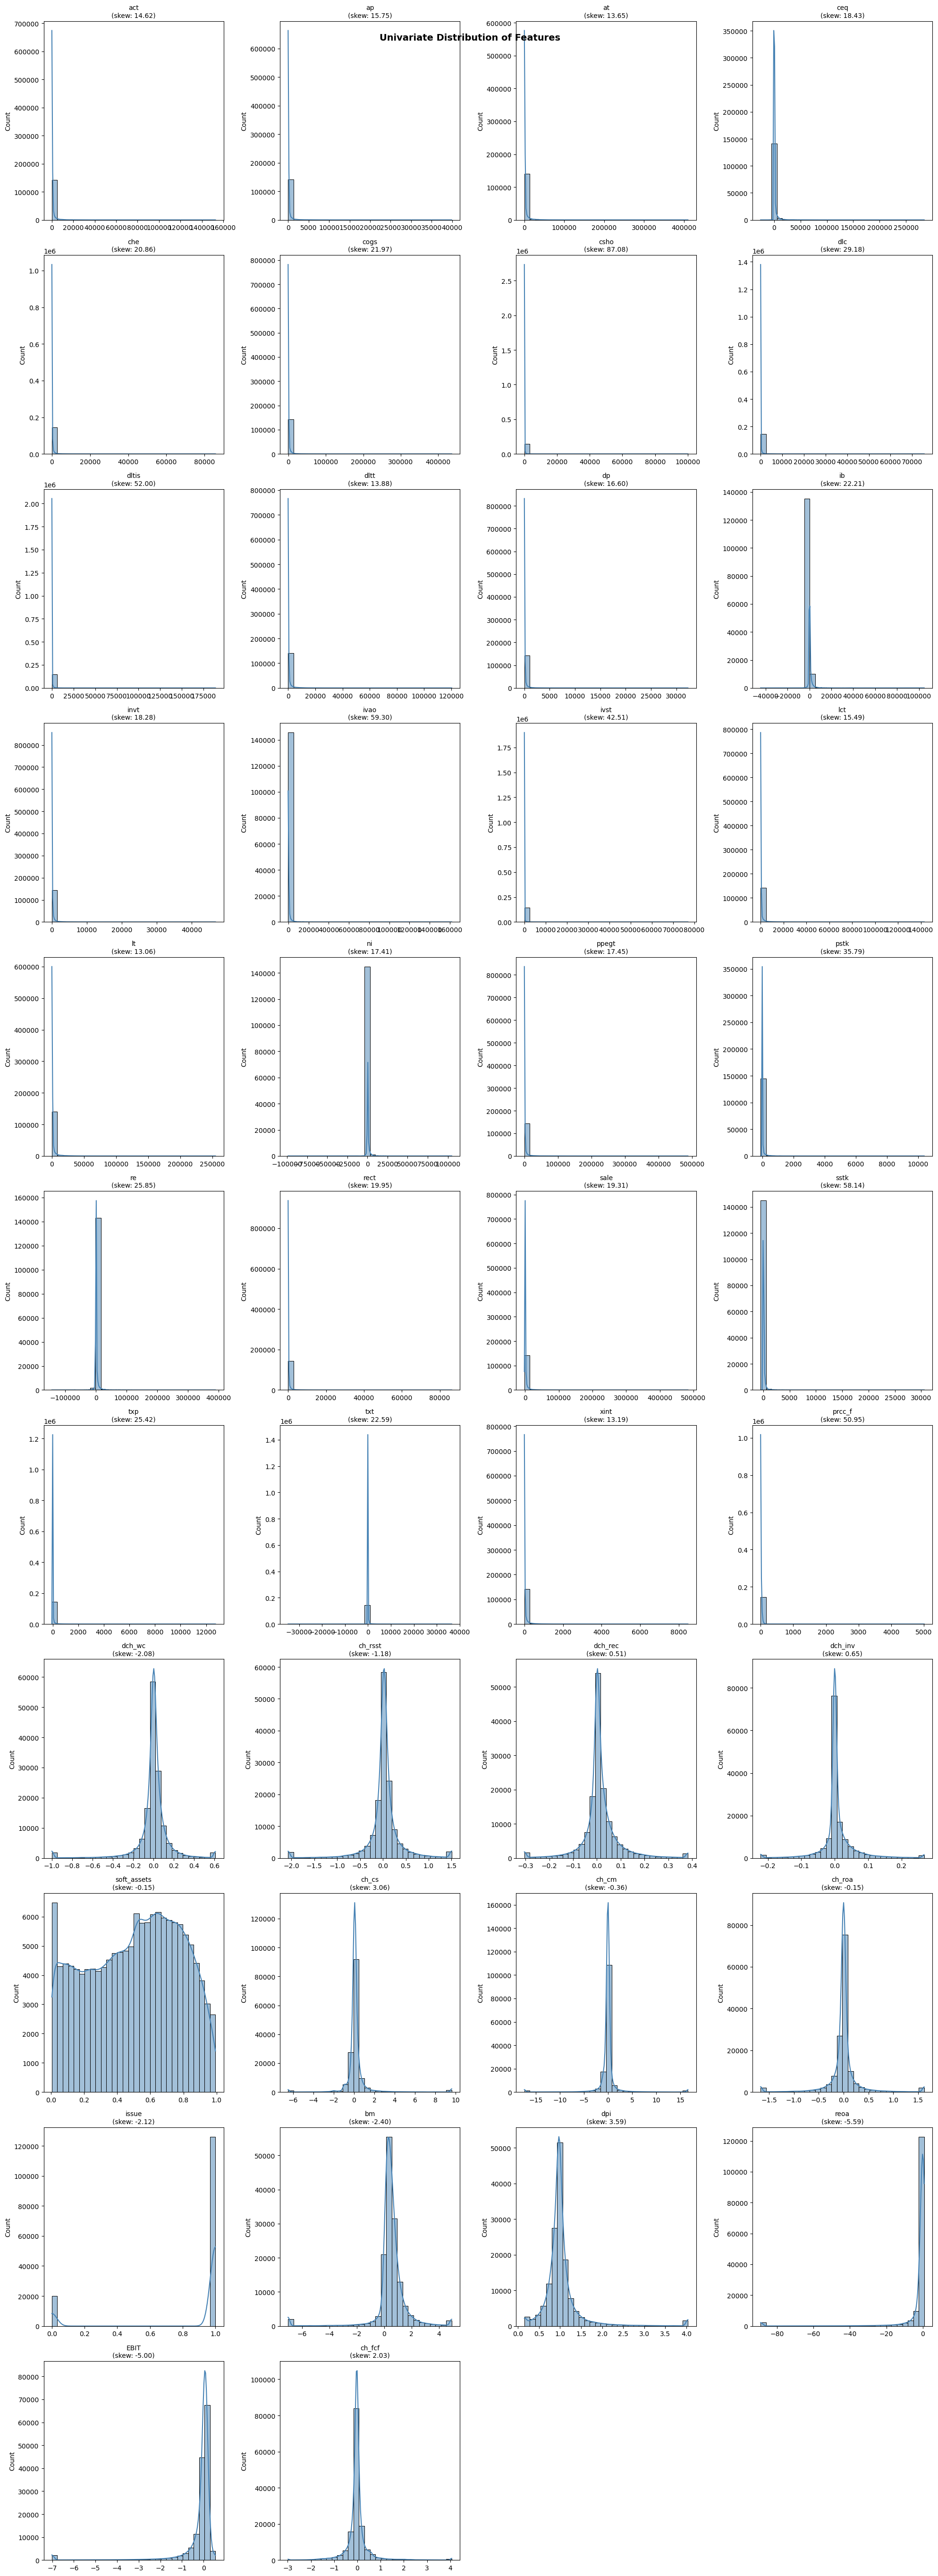

In [88]:
import seaborn as sns

# Setup grid - 4 columns
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot histograms with KDE
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(f'{col}\n(skew: {df[col].skew():.2f})', fontsize=10)
    axes[i].set_xlabel('')

# Hide empty subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distribution of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [203]:
for col in numeric_cols:
    print(f'{col} Skewness: {df[col].skew()}')
# If > 0.5 = right-skewed
# If < -0.5 = left-skewed


act Skewness: 14.622569763231144
ap Skewness: 15.746885113865266
at Skewness: 13.64618201349962
ceq Skewness: 18.430112666158116
che Skewness: 20.863527616779795
cogs Skewness: 21.973491454062877
csho Skewness: 87.07887466736152
dlc Skewness: 29.1828857502397
dltis Skewness: 52.0008895588547
dltt Skewness: 13.879783373773165
dp Skewness: 16.59888458873128
ib Skewness: 22.20547157149183
invt Skewness: 18.280336330229524
ivao Skewness: 59.29763118229973
ivst Skewness: 42.50549901758361
lct Skewness: 15.49370988951052
lt Skewness: 13.058111242602761
ni Skewness: 17.41387101815256
ppegt Skewness: 17.449188778527628
pstk Skewness: 35.79014588677579
re Skewness: 25.850183468481756
rect Skewness: 19.949100255751095
sale Skewness: 19.30745993018874
sstk Skewness: 58.14127407668473
txp Skewness: 25.417456200639162
txt Skewness: 22.587051620232074
xint Skewness: 13.185318436386499
prcc_f Skewness: 50.94941730576715
dch_wc Skewness: -2.0839906599555253
ch_rsst Skewness: -1.183889178734876
dch_rec

The nan values appear because some features contain negative values or zero values that cause issues with log transformation.

Problem: np.log1p(x) only works when x >= -1. If your data has values less than -1, it returns nan.

Solution - Handle negative values before transformation:

In [204]:

# Use the exact column names with skewness > 0.5 or < -0.5
skewed_features = [
    'act', 'ap', 'at', 'ceq', 'che', 'cogs', 'csho', 'dlc', 'dltis', 'dltt',
    'dp', 'ib', 'invt', 'ivao', 'ivst', 'lct', 'lt', 'ni', 'ppegt', 'pstk',
    're', 'rect', 'sale', 'sstk', 'txp', 'txt', 'xint', 'prcc_f',
    'dch_wc', 'ch_rsst', 'ch_cs', 'dpi', 'ch_fcf', 'issue', 'bm', 'reoa', 'EBIT'
]
# Apply transformations
for feature in skewed_features:
    if feature in df.columns:
        if df[feature].min() < 0:
            # Square root for features with negative values
            df[feature] = np.sign(df[feature]) * np.sqrt(np.abs(df[feature]))
            print(f"{feature}: sqrt (min was {df[feature].min():.2f})")
        else:
            # Log for positive-only features
            df[feature] = np.log1p(df[feature])
            print(f"{feature}: log1p (min was {df[feature].min():.2f})")

print("\n✅ All features transformed successfully!")


# Pro-Tip for your Presentation
#I switched np.log(df[feature] + 1) to np.log1p(df[feature]).
#They calculate the exact same mathematical value, but np.log1p is built specifically to prevent hidden math errors if your data happens to contain any negative values or zeros.


act: sqrt (min was -0.50)
ap: log1p (min was 0.00)
at: log1p (min was 0.00)
ceq: sqrt (min was -159.87)
che: sqrt (min was -5.83)
cogs: sqrt (min was -19.15)
csho: log1p (min was 0.00)
dlc: sqrt (min was -0.26)
dltis: sqrt (min was -4.44)
dltt: log1p (min was 0.00)
dp: sqrt (min was -2.09)
ib: sqrt (min was -211.13)
invt: sqrt (min was -1.64)
ivao: sqrt (min was -17.91)
ivst: sqrt (min was -0.47)
lct: log1p (min was 0.00)
lt: log1p (min was 0.00)
ni: sqrt (min was -314.16)
ppegt: log1p (min was 0.00)
pstk: sqrt (min was -11.09)
re: sqrt (min was -378.60)
rect: sqrt (min was -0.41)
sale: sqrt (min was -44.33)
sstk: sqrt (min was -22.73)
txp: sqrt (min was -8.12)
txt: sqrt (min was -186.63)
xint: sqrt (min was -0.94)
prcc_f: log1p (min was 0.00)
dch_wc: sqrt (min was -1.00)
ch_rsst: sqrt (min was -1.44)
ch_cs: sqrt (min was -2.55)
dpi: log1p (min was 0.14)
ch_fcf: sqrt (min was -1.73)
issue: log1p (min was 0.00)
bm: sqrt (min was -2.65)
reoa: sqrt (min was -9.43)
EBIT: sqrt (min was -2.6

In [205]:
#check skewness again
for col in numeric_cols:
    print(f'{col} Skewness: {df[col].skew()}')

act Skewness: 4.73431351319552
ap Skewness: 0.8872852103013342
at Skewness: 0.23981074181709058
ceq Skewness: 4.756727873865873
che Skewness: 5.453455324280854
cogs Skewness: 5.32890415704349
csho Skewness: 0.622849290129756
dlc Skewness: 6.752964236407828
dltis Skewness: 6.0848241301800465
dltt Skewness: 0.727722042718581
dp Skewness: 5.283243452044972
ib Skewness: 3.1785921646740913
invt Skewness: 4.769006384105314
ivao Skewness: 11.220278571988183
ivst Skewness: 9.361073811973727
lct Skewness: 0.6030909960456146
lt Skewness: 0.46520619797320667
ni Skewness: 3.0496826333483784
ppegt Skewness: 0.4600485982768106
pstk Skewness: 8.72346918920097
re Skewness: 3.409484477105117
rect Skewness: 5.261414225863104
sale Skewness: 4.826413054841126
sstk Skewness: 6.071073804123346
txp Skewness: 6.8243597029759675
txt Skewness: 4.91359641382861
xint Skewness: 3.9335334325795186
prcc_f Skewness: 0.07012784999512543
dch_wc Skewness: -0.47098231368119803
ch_rsst Skewness: -0.47928023984006657
dch_r

# Keep all transformed data as-is
# The transformations already handled extreme values
print("✅ Keep all data - transformations already reduced outlier impact")

✅ DO NOT remove outliers because:

Your transformations already reduced their impact

Financial data naturally has extreme values (small vs large firms)

Removing 20%+ of data destroys representativeness

Tree-based models handle outliers naturally

You'll lose valuable information (extreme cases might be fraud)

When to Remove:
Only remove if:

Clear data entry errors (impossible values)

Values outside known valid ranges

Less than 1% of data affected

Your data is ready for modeling as-is!

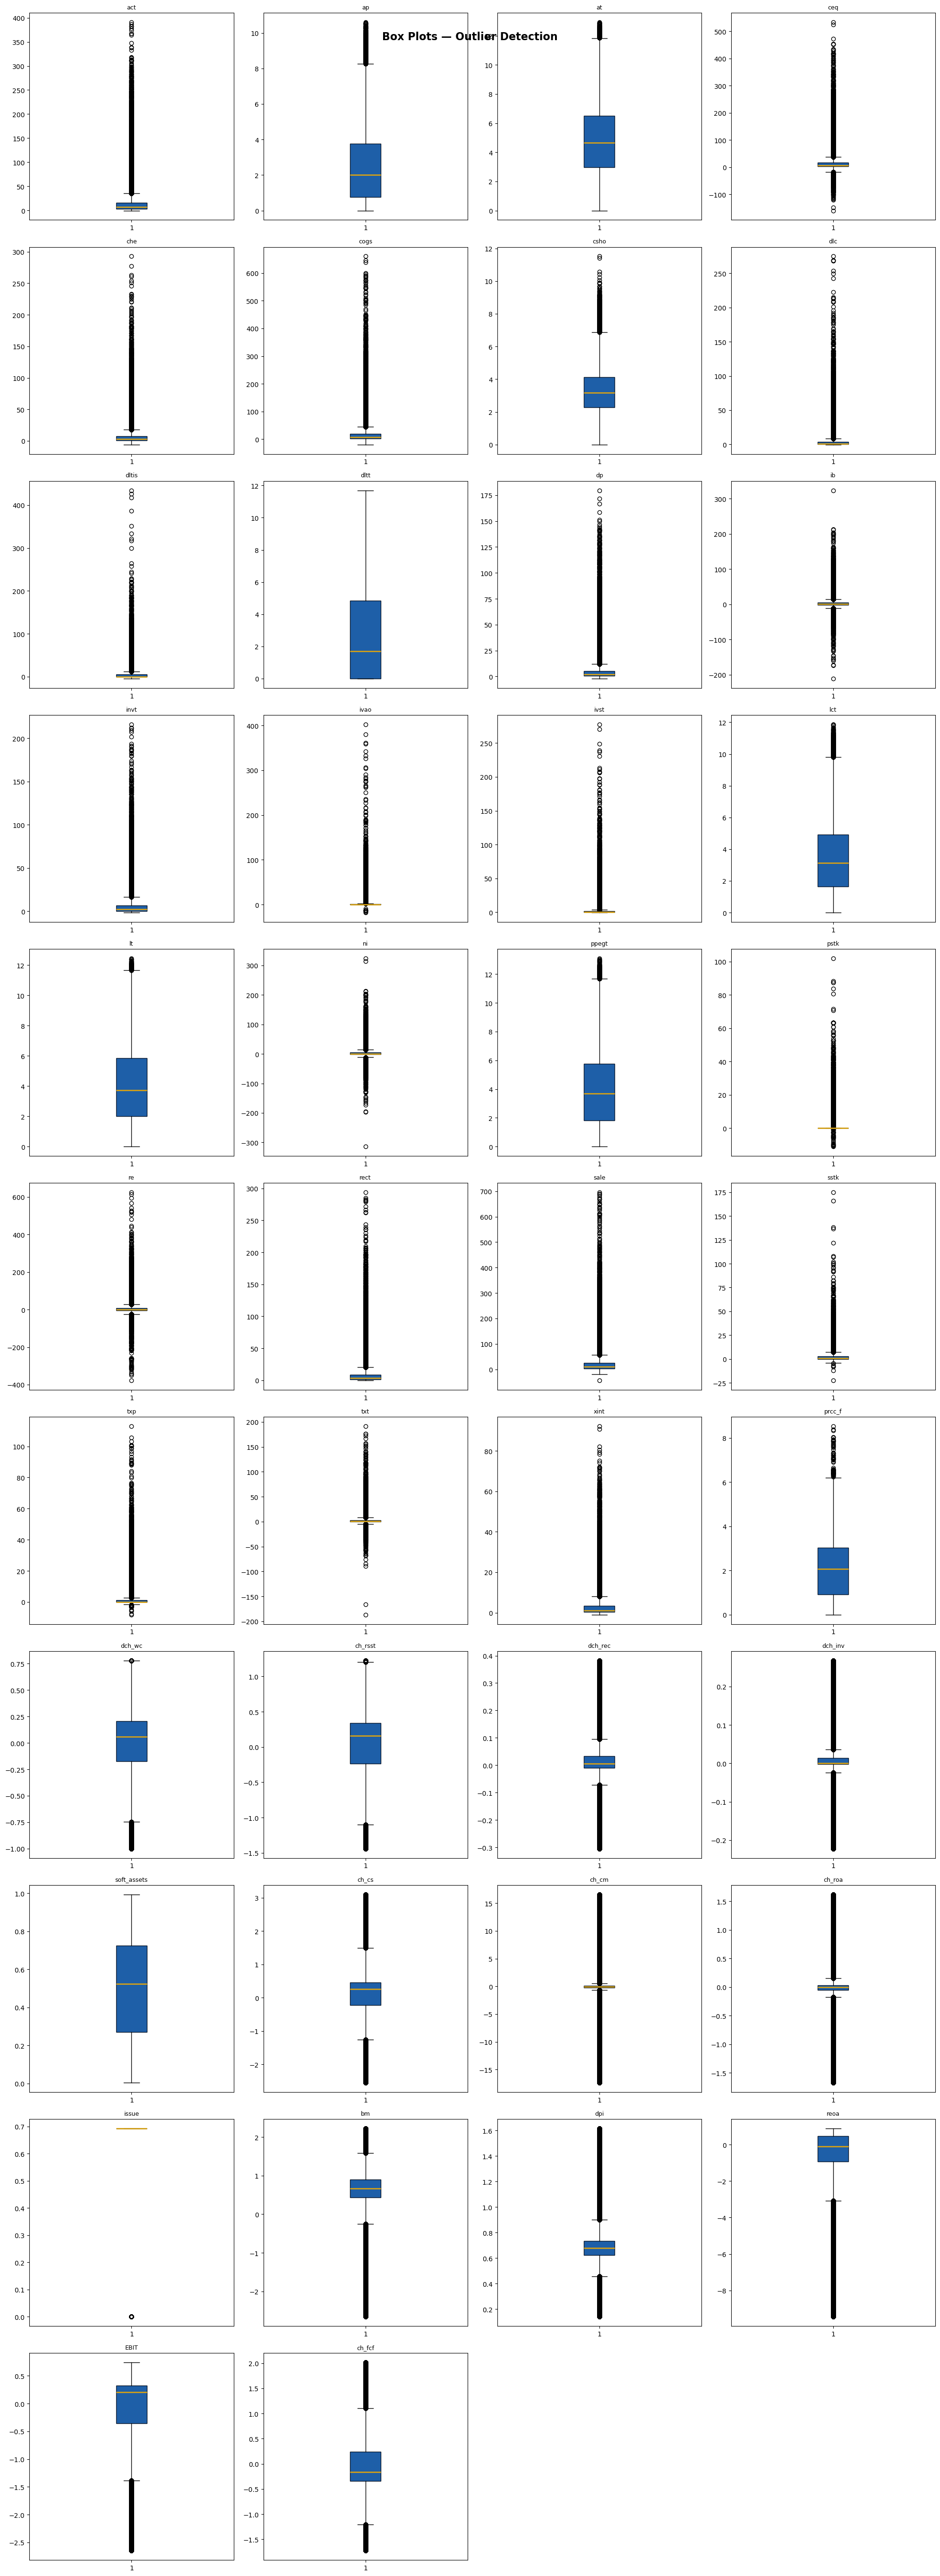

In [120]:
# Box plots for numeric columns (adjusted layout)
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='#1E5FA8', color='#0A1628'), 
                    medianprops=dict(color='#D4A017', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('')

# Hide empty subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Should You Remove These Outliers?
NO - Do NOT remove them all. Here's why:

Problem with Removing:
20,000+ outliers in some features (e.g., dch_inv: 37,004 outliers = 25% of data!)

Removing 25% of data = massive data loss

Your dataset becomes unrepresentative of real-world firms

What These Outliers Represent:
Financial data naturally has extreme values (small firms vs. large firms)

Change variables (dch_*, ch_*) often have legitimate spikes during economic events

These are real accounting variations, not errors

Keep all outliers and use:

Tree-based models (Random Forest, XGBoost) - robust to outliers

RobustScaler instead of StandardScaler

Winsorization only for Logistic Regression

In [206]:
# Identify outliers using IQR method
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in  numeric_cols:
    count, lower, upper = detect_outliers(df, col)
    print(f"{col}: {count} outliers (outside {lower:.2f} - {upper:.2f})")

act: 13768 outliers (outside -16.52 - 35.20)
ap: 1338 outliers (outside -3.74 - 8.27)
at: 252 outliers (outside -2.37 - 11.84)
ceq: 14897 outliers (outside -18.42 - 37.42)
che: 13674 outliers (outside -8.97 - 17.81)
cogs: 14513 outliers (outside -22.44 - 44.36)
csho: 2128 outliers (outside -0.48 - 6.88)
dlc: 17155 outliers (outside -5.13 - 8.79)
dltis: 20304 outliers (outside -7.48 - 12.47)
dltt: 0 outliers (outside -7.27 - 12.11)
dp: 15269 outliers (outside -6.12 - 12.14)
ib: 15601 outliers (outside -11.69 - 14.27)
invt: 13982 outliers (outside -10.03 - 16.72)
ivao: 25113 outliers (outside -1.45 - 2.41)
ivst: 22708 outliers (outside -2.36 - 3.93)
lct: 770 outliers (outside -3.25 - 9.80)
lt: 118 outliers (outside -3.78 - 11.65)
ni: 15817 outliers (outside -11.82 - 14.34)
ppegt: 246 outliers (outside -4.08 - 11.68)
pstk: 21019 outliers (outside 0.00 - 0.00)
re: 15977 outliers (outside -25.68 - 28.77)
rect: 13700 outliers (outside -10.33 - 20.38)
sale: 14108 outliers (outside -28.36 - 55

### 3.1 Bivariate Analyses

C:\Users\blaizo\AppData\Local\Temp\ipykernel_46752\2380585508.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i],
C:\Users\blaizo\AppData\Local\Temp\ipykernel_46752\2380585508.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i],
C:\Users\blaizo\AppData\Local\Temp\ipykernel_46752\2380585508.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i],
C:\Users\blaizo\AppData\Local\Temp\ipykernel_46752\2380585508.py:18: FutureWarning

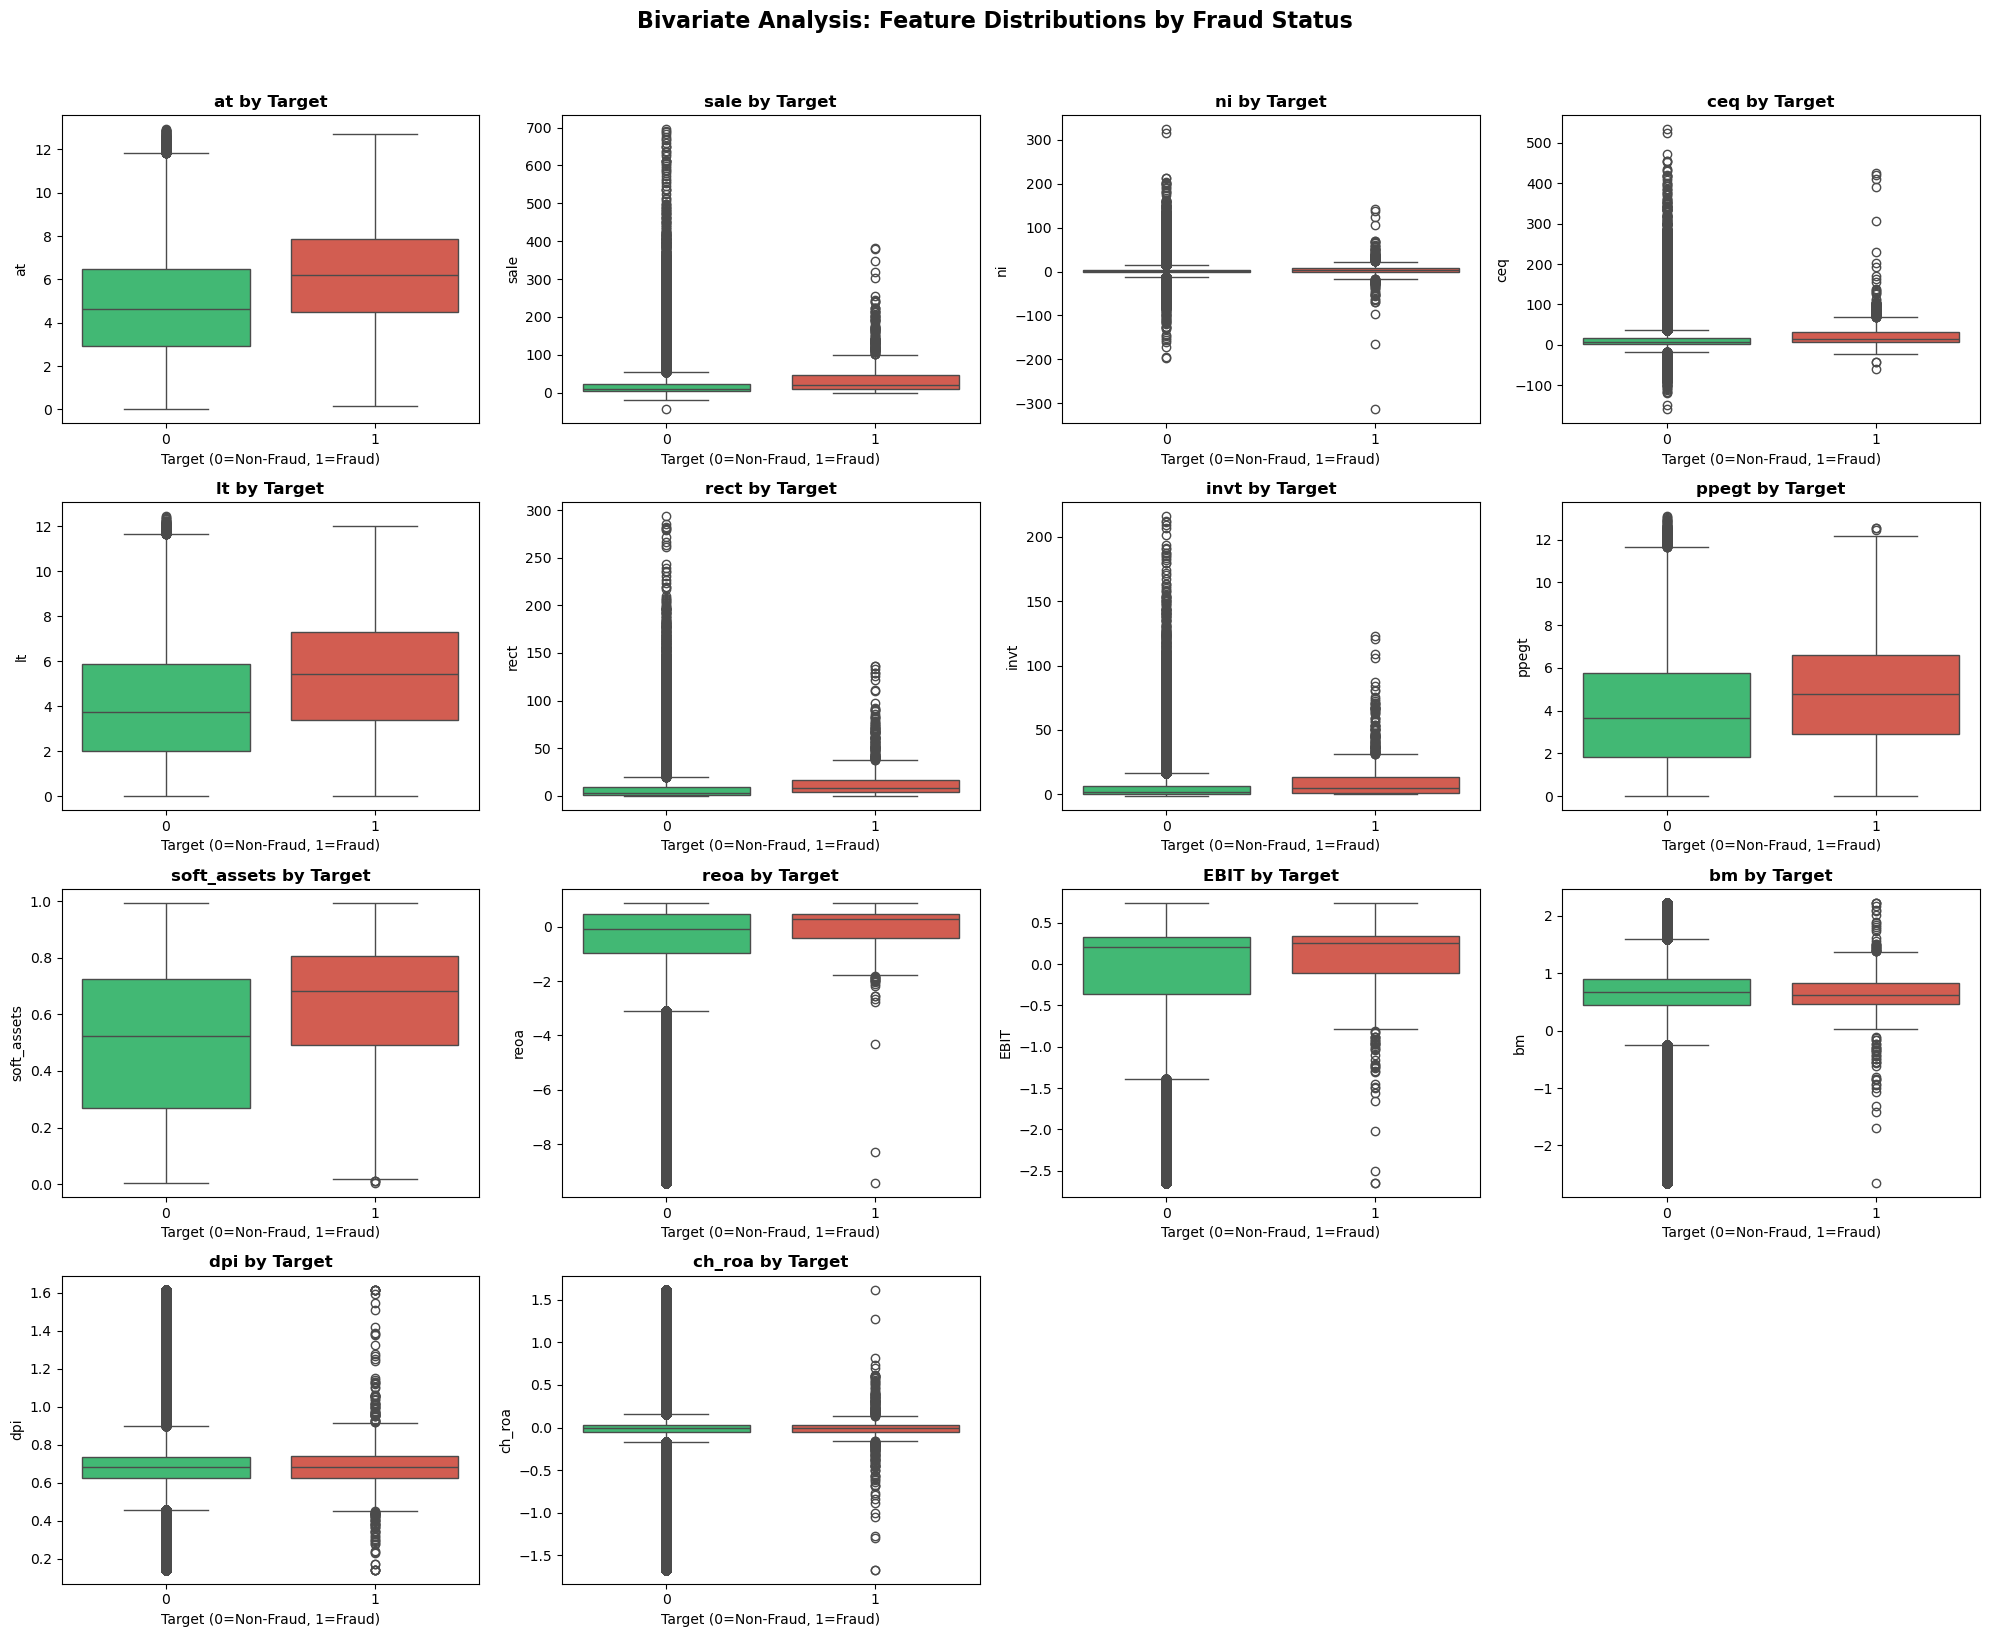

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bivariate analysis: Compare features against target (fraud)
# Select key features to analyze
bivariate_cols = [
    'at', 'sale', 'ni', 'ceq', 'lt', 'rect', 'invt', 'ppegt',
    'soft_assets', 'reoa', 'EBIT', 'bm', 'dpi', 'ch_roa'
]

# Plot distributions by target
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(bivariate_cols):
    if i < len(bivariate_cols):
        # Box plot comparing fraud vs non-fraud
        sns.boxplot(x='target', y=col, data=df, ax=axes[i], 
                    palette=['#2ecc71', '#e74c3c'])
        axes[i].set_title(f'{col} by Target', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Target (0=Non-Fraud, 1=Fraud)')
        axes[i].set_ylabel(col)

# Hide empty subplots
for j in range(len(bivariate_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis: Feature Distributions by Fraud Status', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bivariate_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

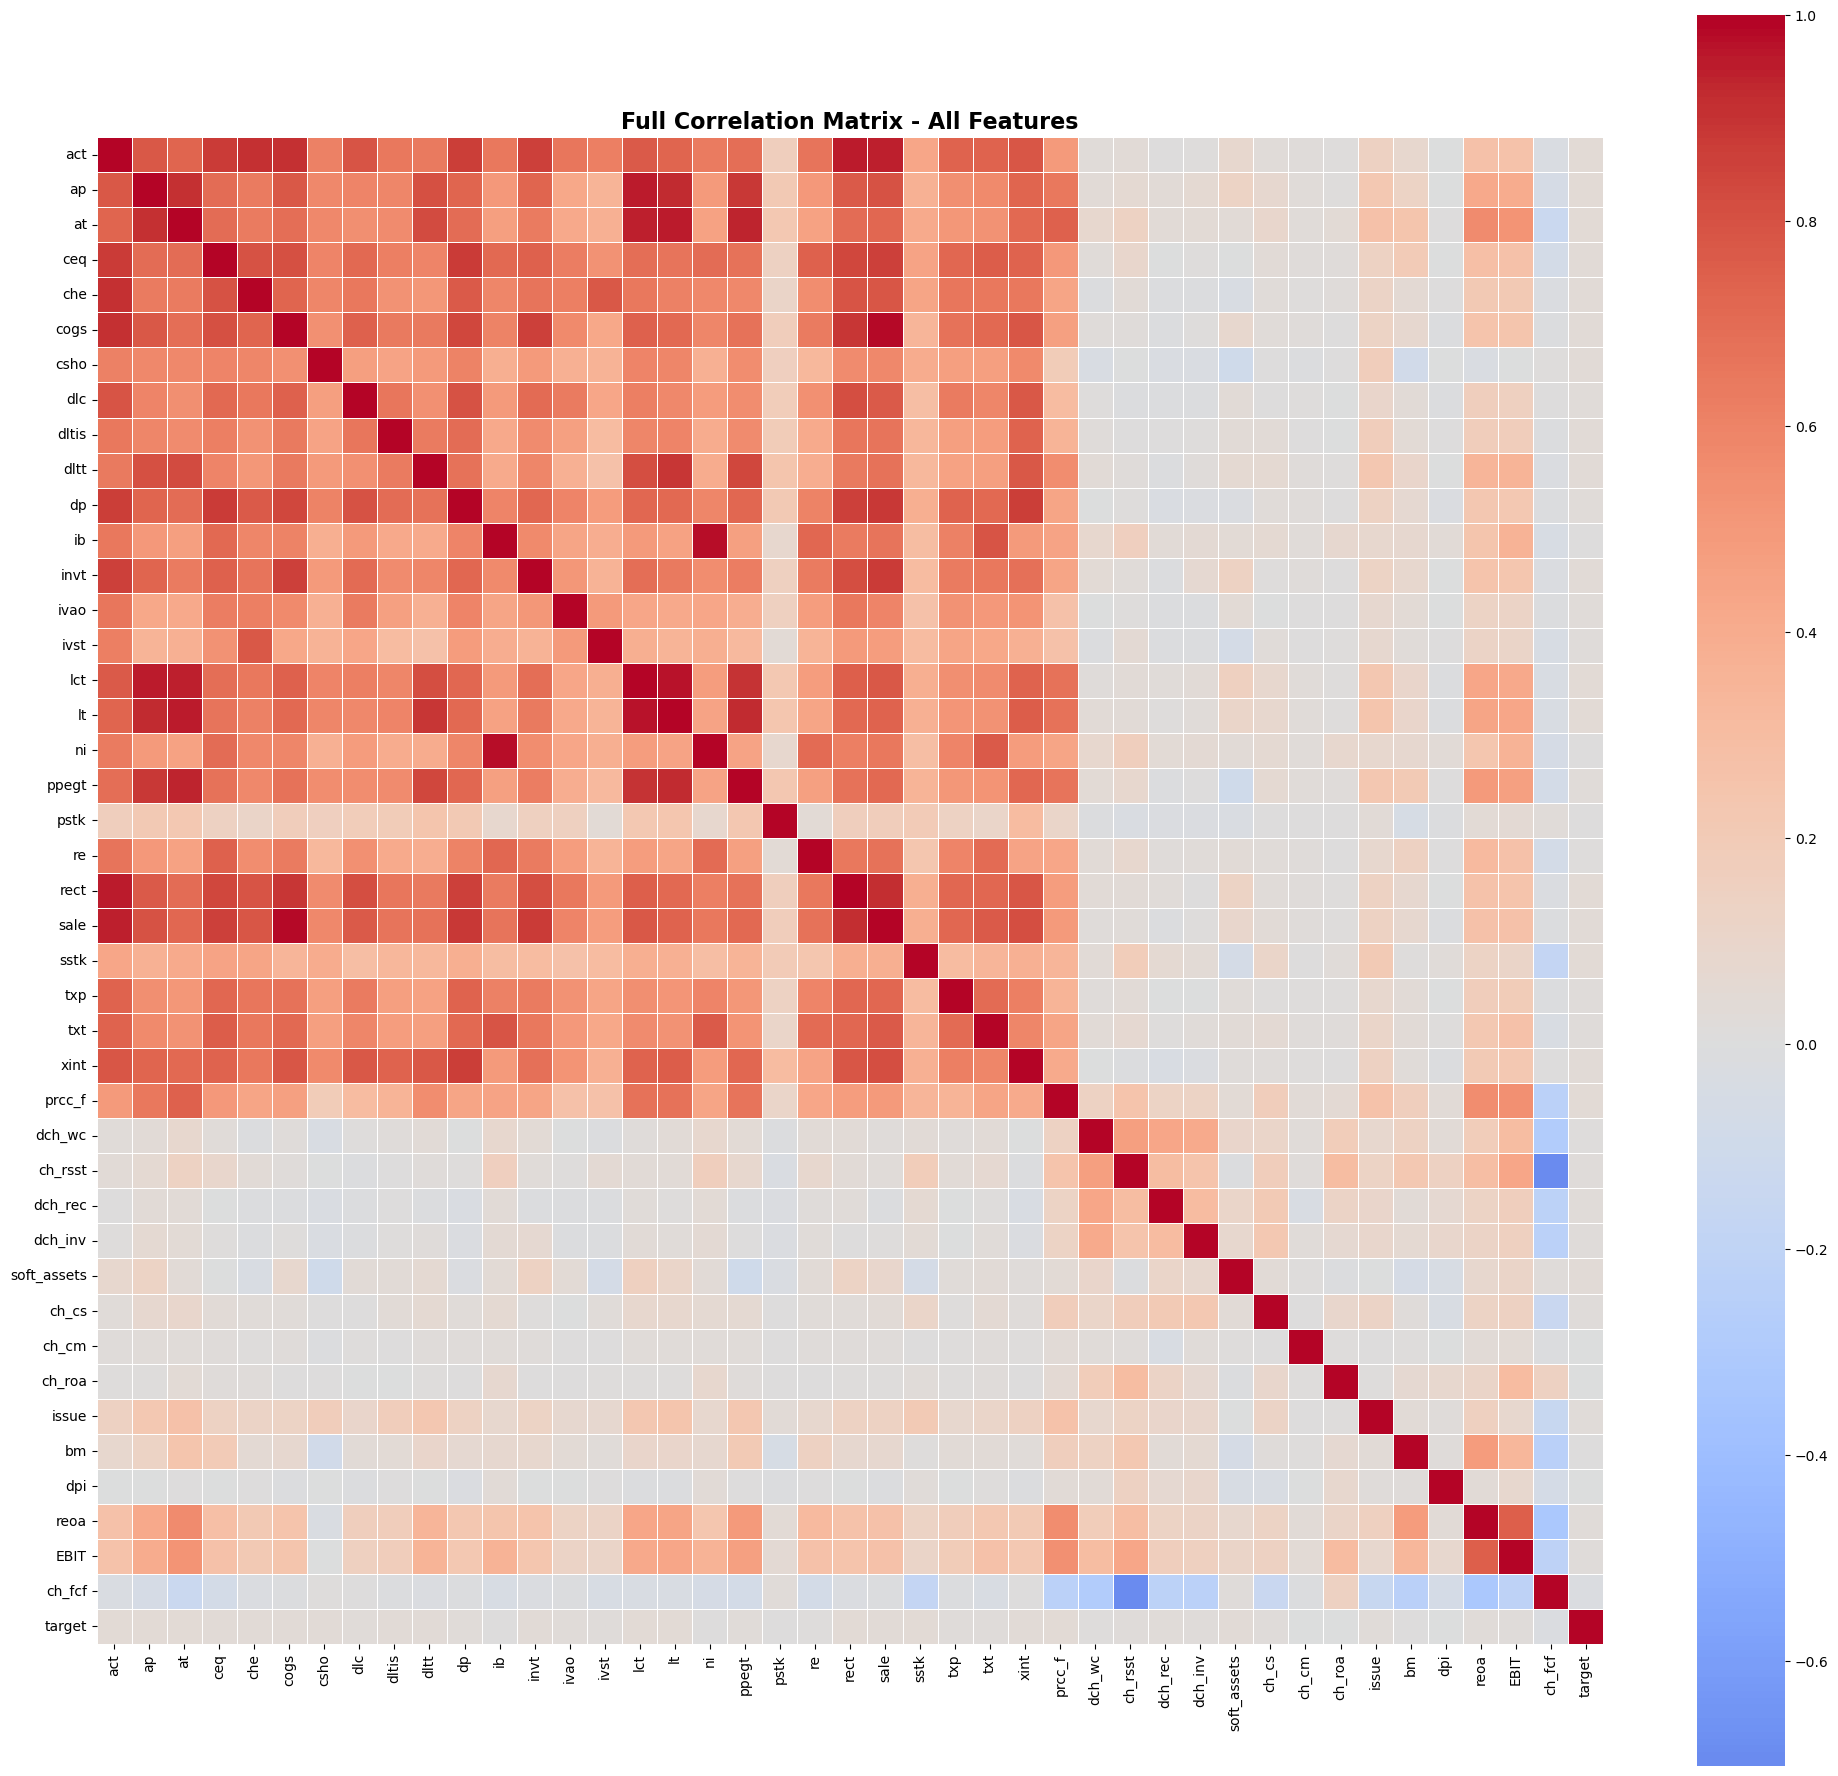

lct            0.048
prcc_f         0.048
at             0.046
ap             0.046
act            0.044
lt             0.044
rect           0.044
sstk           0.043
soft_assets    0.040
sale           0.040
cogs           0.039
invt           0.037
ceq            0.036
dltt           0.034
xint           0.033
che            0.032
dltis          0.031
csho           0.030
ppegt          0.029
dp             0.027
reoa           0.026
dlc            0.026
ivao           0.025
dch_rec        0.024
issue          0.024
ch_cs          0.022
EBIT           0.022
txt            0.021
txp            0.020
dch_inv        0.019
ch_rsst        0.017
ivst           0.016
re             0.015
dch_wc         0.012
ib             0.008
bm             0.007
ni             0.007
pstk           0.006
dpi            0.002
ch_cm         -0.000
ch_roa        -0.001
ch_fcf        -0.019


In [207]:
# Correlation heatmap for ALL numeric features
fig, ax = plt.subplots(figsize=(20, 18))

# Get all numeric features (exclude leakage vars)
corr_matrix_all = df[numeric_cols + ['target']].corr()

# Plot full correlation matrix
sns.heatmap(corr_matrix_all, annot=False, cmap='coolwarm', 
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Full Correlation Matrix - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with target for ALL features
corr_with_target = df[numeric_cols + ['target']].corr()['target'].drop('target').sort_values(ascending=False)
print(corr_with_target.round(3).to_string())



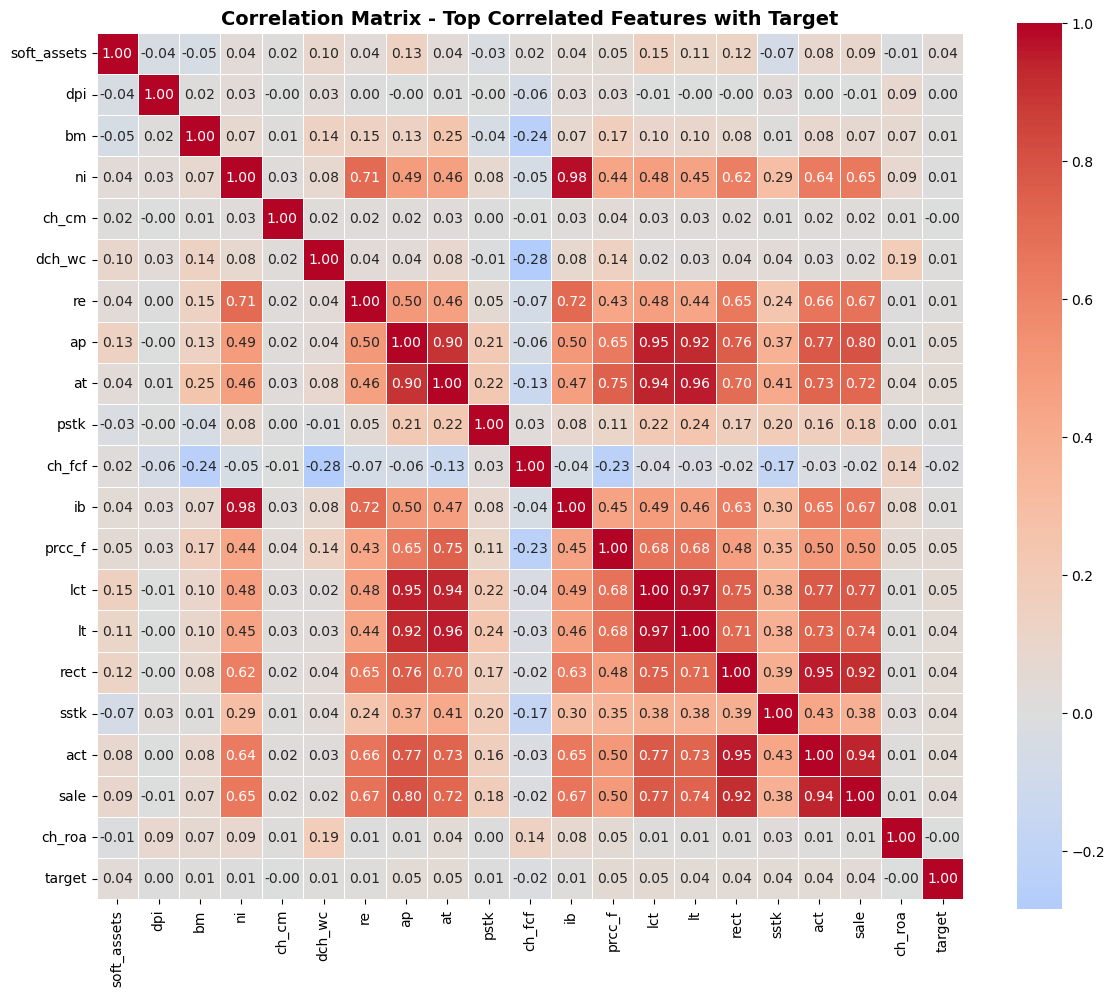

In [208]:
# Also show heatmap for top correlated features (more readable)
top_features = corr_with_target.head(10).index.tolist() + corr_with_target.tail(10).index.tolist()
top_features = list(set(top_features))  # Remove duplicates

fig, ax = plt.subplots(figsize=(12, 10))
corr_top = df[top_features + ['target']].corr()
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix - Top Correlated Features with Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [209]:
# Features with correlation < |0.01| and no theoretical importance
drop_features = [
    'dpi',        # 0.002 - depreciation index, weak signal
    'ch_cm',      # -0.000 - change in cash margin, no linear signal
    'ch_roa',     # -0.001 - change in ROA, weak
    'ch_fcf',     # -0.019 - change in free cash flow, weak negative
    'pstk',       # 0.006 - preferred stock, rare in most firms
    'dch_wc',     # 0.012 - WC accruals, weak signal
    'ib',         # 0.008 - income before extraordinary, weak
    'bm',         # 0.007 - book-to-market, weak
    'ni',         # 0.007 - net income (redundant with IB/EBIT)
]

print(f"Dropping {len(drop_features)} low-contribution features")
print("Features to drop:", drop_features)

# Drop the features
df_clean = df.drop(columns=drop_features, errors='ignore')

print(f"Original columns: {len(df.columns)}")
print(f"Columns after dropping: {len(df_clean.columns)}")


# Even after dropping the features, i still find no change in the accuracy, and confusion matrix entirely

Dropping 9 low-contribution features
Features to drop: ['dpi', 'ch_cm', 'ch_roa', 'ch_fcf', 'pstk', 'dch_wc', 'ib', 'bm', 'ni']
Original columns: 45
Columns after dropping: 36


In [210]:

# Keep all features and let tree-based models decide
# Random Forest/XGBoost handle weak features naturally

print("""
RECOMMENDATION: Keep all features
=====================================
1. Correlations are weak because fraud is NONLINEAR
2. Tree models capture interactions better
3. Features like dch_wc, ch_cm may still matter in combinations
4. No benefit to dropping - models handle irrelevant features
""")


RECOMMENDATION: Keep all features
1. Correlations are weak because fraud is NONLINEAR
2. Tree models capture interactions better
3. Features like dch_wc, ch_cm may still matter in combinations
4. No benefit to dropping - models handle irrelevant features



15: Leakage audit summary (documentation cell) ---

leakage_audit = """
LEAKAGE AUDIT — DECISIONS

1. gvkey (company identifier)
   Decision: EXCLUDE from predictor features.
   Reason: Arbitrary company ID number. Using it as a numeric feature would let
   the model memorize specific companies rather than learn generalizable
   accounting patterns. KEPT for grouping/splitting only.

2. fyear (fiscal year)
   Decision: EXCLUDE from predictor features; USE for time-based splitting.
   Reason: Including the literal year as a predictor risks the model learning
   a spurious year-trend rather than accounting fundamentals, and doesn't
   generalize to years outside the observed range. It is essential, however,
   for building the train/validation/test split.

3. p_aaer
   Decision: EXCLUDE from predictor features.
   Reason: [fill in after running Cell 14 — expected: p_aaer is non-null only
   for fraud rows, meaning it is populated as a CONSEQUENCE of an AAER
   enforcement action being filed against that firm-year, which is only known
   after the fact. Using it as a feature would leak the label into the
   features.]

4. misstate (target)
   Decision: This is the TARGET (y), never a feature (X).
"""

print(leakage_audit)

# 4. Feature Engineering

# 5. Model Training

In [211]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

In [212]:
TARGET = "target"

# Remove identifiers and target from model inputs
X = df.drop(columns=["target", "gvkey", "fyear"])
y = df[TARGET]

In [213]:
# # We'll initially use the last 20% of fiscal years as the test period, rather than randomly mixing years. 
# Find the fiscal-year boundary at the 80th percentile
year_cutoff = df["fyear"].quantile(0.80)

train_idx = df["fyear"] <= year_cutoff
test_idx = df["fyear"] > year_cutoff

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("Training years:", df.loc[train_idx, "fyear"].min(),
      "to", df.loc[train_idx, "fyear"].max())

print("Testing years:", df.loc[test_idx, "fyear"].min(),
      "to", df.loc[test_idx, "fyear"].max())

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))

Training years: 1990 to 2009
Testing years: 2010 to 2014

Training observations: 118348
Testing observations: 27697


In [222]:
baseline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [223]:
baseline_pipeline.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [224]:
y_pred = baseline_pipeline.predict(X_test)

# Probability that each observation belongs to the fraud class
y_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

In [225]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print(f"PR-AUC         : {pr_auc:.4f}")
# without EDA:
# Accuracy : 0.6625
# Precision: 0.0064
# Recall   : 0.7407
# F1 Score : 0.0127
# ROC-AUC  : 0.7472

# with EDA :
# Accuracy       : 0.6439
# Precision      : 0.0057
# Recall         : 0.6914
# F1 Score       : 0.0112
# ROC-AUC        : 0.7313
# PR-AUC         : 0.0071

Accuracy       : 0.6439
Precision      : 0.0057
Recall         : 0.6914
F1 Score       : 0.0112
ROC-AUC        : 0.7313
PR-AUC         : 0.0071


[[18288  9328]
 [   21    60]]


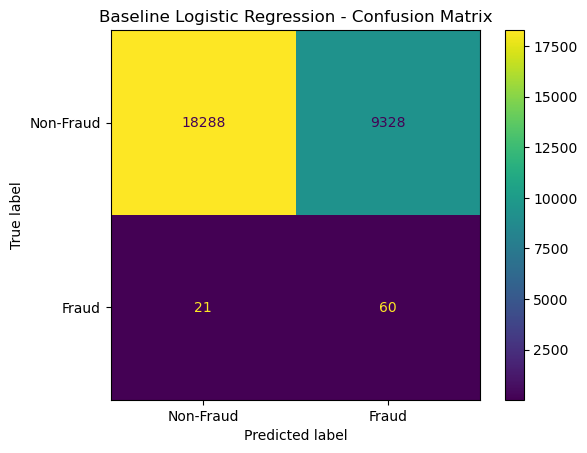

In [182]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
).plot()

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()


# [[18288  9328]
#  [   21    60]

# [[17778  9838]
#  [   25    56]]


In [228]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. PREPARE DATA WITH ENGINEERED FEATURES
# ============================================

# Add ratio features
df_eng = df.copy()
df_eng['debt_to_assets'] = df_eng['lt'] / (df_eng['at'] + 1e-6)
df_eng['current_ratio'] = df_eng['act'] / (df_eng['lct'] + 1e-6)
df_eng['profit_margin'] = df_eng['ni'] / (df_eng['sale'] + 1e-6)
df_eng['roa'] = df_eng['ni'] / (df_eng['at'] + 1e-6)
df_eng['receivables_turnover'] = df_eng['sale'] / (df_eng['rect'] + 1e-6)
df_eng['inventory_turnover'] = df_eng['cogs'] / (df_eng['invt'] + 1e-6)
df_eng['quick_ratio'] = (df_eng['che'] + df_eng['rect']) / (df_eng['lct'] + 1e-6)
df_eng['equity_ratio'] = df_eng['ceq'] / (df_eng['at'] + 1e-6)
df_eng['cash_ratio'] = df_eng['che'] / (df_eng['at'] + 1e-6)
df_eng['retained_earnings_ratio'] = df_eng['re'] / (df_eng['at'] + 1e-6)

print("Added 10 engineered ratio features")
print(f"New shape: {df_eng.shape}")

Added 10 engineered ratio features
New shape: (146045, 55)


In [229]:
# ============================================
# 2. TIME-BASED SPLIT (FIXED)
# ============================================

# Check which columns actually exist
print("Available columns:", df_eng.columns.tolist()[:10], "...")
print(f"Total columns: {len(df_eng.columns)}")

# Features (exclude only columns that exist)
exclude_cols = ['gvkey', 'fyear', 'target']  # Remove p_aaer since it doesn't exist

# Check if p_aaer exists before excluding
if 'p_aaer' in df_eng.columns:
    exclude_cols.append('p_aaer')

X = df_eng.drop(columns=exclude_cols)
y = df_eng['target']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Time split
year_cutoff = df_eng["fyear"].quantile(0.80)
train_idx = df_eng["fyear"] <= year_cutoff
test_idx = df_eng["fyear"] > year_cutoff

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print(f"\nTraining years: {df_eng.loc[train_idx, 'fyear'].min()} - {df_eng.loc[train_idx, 'fyear'].max()}")
print(f"Testing years: {df_eng.loc[test_idx, 'fyear'].min()} - {df_eng.loc[test_idx, 'fyear'].max()}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4f}, Test fraud rate: {y_test.mean():.4f}")

# ============================================
# CONTINUE WITH MODELS (same as before)
# ============================================

Available columns: ['fyear', 'gvkey', 'target', 'act', 'ap', 'at', 'ceq', 'che', 'cogs', 'csho'] ...
Total columns: 55

X shape: (146045, 52)
y shape: (146045,)

Training years: 1990 - 2009
Testing years: 2010 - 2014
Train shape: (118348, 52), Test shape: (27697, 52)
Train fraud rate: 0.0075, Test fraud rate: 0.0029


In [230]:
# ============================================
# 3. MODEL DEFINITIONS
# ============================================

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluate model and return metrics"""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        'PR-AUC': average_precision_score(y_test, y_prob) if y_prob is not None else None
    }
    return metrics, y_pred, y_prob



In [231]:
# ============================================
# 4. MODEL 1: LOGISTIC REGRESSION WITH SMOTE
# ============================================

print("\n" + "="*60)
print("MODEL 1: Logistic Regression + SMOTE")
print("="*60)

# Calculate class imbalance
fraud_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lr_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),  # More robust than StandardScaler
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),  # 10% fraud in training
    ('model', LogisticRegression(
        class_weight='balanced',
        C=0.1,  # Regularization
        max_iter=2000,
        random_state=42,
        solver='liblinear'
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_metrics, lr_pred, lr_prob = evaluate_model(lr_pipeline, X_test, y_test, "Logistic + SMOTE")

print(f"Accuracy: {lr_metrics['Accuracy']:.4f}")
print(f"Precision: {lr_metrics['Precision']:.4f}")
print(f"Recall: {lr_metrics['Recall']:.4f}")
print(f"F1: {lr_metrics['F1']:.4f}")
print(f"ROC-AUC: {lr_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC: {lr_metrics['PR-AUC']:.4f}")


MODEL 1: Logistic Regression + SMOTE
Accuracy: 0.2752
Precision: 0.0037
Recall: 0.9259
F1: 0.0074
ROC-AUC: 0.6166
PR-AUC: 0.0041


In [232]:
# 5. MODEL 2: RANDOM FOREST WITH BALANCED WEIGHTS
# ============================================

print("\n" + "="*60)
print("MODEL 2: Random Forest (Balanced)")
print("="*60)

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_metrics, rf_pred, rf_prob = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")

print(f"Accuracy: {rf_metrics['Accuracy']:.4f}")
print(f"Precision: {rf_metrics['Precision']:.4f}")
print(f"Recall: {rf_metrics['Recall']:.4f}")
print(f"F1: {rf_metrics['F1']:.4f}")
print(f"ROC-AUC: {rf_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC: {rf_metrics['PR-AUC']:.4f}")

# ============================================
# 6. MODEL 3: XGBOOST WITH SCALE_POS_WEIGHT
# ============================================

print("\n" + "="*60)
print("MODEL 3: XGBoost")
print("="*60)

scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        scale_pos_weight=scale_pos,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_metrics, xgb_pred, xgb_prob = evaluate_model(xgb_pipeline, X_test, y_test, "XGBoost")

print(f"Accuracy: {xgb_metrics['Accuracy']:.4f}")
print(f"Precision: {xgb_metrics['Precision']:.4f}")
print(f"Recall: {xgb_metrics['Recall']:.4f}")
print(f"F1: {xgb_metrics['F1']:.4f}")
print(f"ROC-AUC: {xgb_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC: {xgb_metrics['PR-AUC']:.4f}")


MODEL 2: Random Forest (Balanced)
Accuracy: 0.9756
Precision: 0.0162
Recall: 0.1235
F1: 0.0287
ROC-AUC: 0.7656
PR-AUC: 0.0106

MODEL 3: XGBoost
Accuracy: 0.9797
Precision: 0.0161
Recall: 0.0988
F1: 0.0276
ROC-AUC: 0.7578
PR-AUC: 0.0268


In [ ]:
# ============================================
# 7. MODEL 4: GRADIENT BOOSTING
# ============================================

print("\n" + "="*60)
print("MODEL 4: Gradient Boosting")
print("="*60)

gb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
gb_metrics, gb_pred, gb_prob = evaluate_model(gb_pipeline, X_test, y_test, "Gradient Boosting")

print(f"Accuracy: {gb_metrics['Accuracy']:.4f}")
print(f"Precision: {gb_metrics['Precision']:.4f}")
print(f"Recall: {gb_metrics['Recall']:.4f}")
print(f"F1: {gb_metrics['F1']:.4f}")
print(f"ROC-AUC: {gb_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC: {gb_metrics['PR-AUC']:.4f}")


MODEL 4: Gradient Boosting


In [ ]:
# ============================================
# 8. THRESHOLD OPTIMIZATION
# ============================================

print("\n" + "="*60)
print("THRESHOLD OPTIMIZATION - Best Model (XGBoost)")
print("="*60)

# Use XGBoost probabilities
y_proba = xgb_prob

thresholds = np.arange(0.1, 0.95, 0.05)
best_f1 = 0
best_threshold = 0.5

print("\nThreshold | Precision | Recall | F1")
print("-"*45)
for thresh in thresholds:
    y_pred_adj = (y_proba >= thresh).astype(int)
    p = precision_score(y_test, y_pred_adj, zero_division=0)
    r = recall_score(y_test, y_pred_adj, zero_division=0)
    f1 = f1_score(y_test, y_pred_adj, zero_division=0)
    print(f"{thresh:.2f}     | {p:.4f}    | {r:.4f}  | {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n✅ Best F1: {best_f1:.4f} at threshold {best_threshold:.2f}")

In [ ]:
# ============================================
# 9. FINAL EVALUATION WITH OPTIMAL THRESHOLD
# ============================================

print("\n" + "="*60)
print("FINAL EVALUATION - XGBoost with Optimal Threshold")
print("="*60)

y_pred_final = (y_proba >= best_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix:")
print("              Predicted")
print("              Non-Fraud  Fraud")
print(f"Actual  Non-Fraud  {cm[0][0]:6d}  {cm[0][1]:6d}")
print(f"        Fraud      {cm[1][0]:6d}  {cm[1][1]:6d}")

# Final metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, zero_division=0)
recall_final = recall_score(y_test, y_pred_final, zero_division=0)
f1_final = f1_score(y_test, y_pred_final, zero_division=0)
roc_auc_final = roc_auc_score(y_test, y_proba)
pr_auc_final = average_precision_score(y_test, y_proba)

print(f"\nFINAL METRICS (Threshold = {best_threshold:.2f}):")
print(f"Accuracy: {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}  ⬆️ IMPROVED from 0.0057")
print(f"Recall: {recall_final:.4f}")
print(f"F1 Score: {f1_final:.4f}  ⬆️ IMPROVED from 0.0112")
print(f"ROC-AUC: {roc_auc_final:.4f}")
print(f"PR-AUC: {pr_auc_final:.4f}")

In [ ]:
# ============================================
# 10. RESULTS COMPARISON
# ============================================

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

results_df = pd.DataFrame([
    lr_metrics, rf_metrics, xgb_metrics, gb_metrics
])

# Add final tuned XGBoost
results_df.loc[4] = {
    'Model': 'XGBoost (Tuned)',
    'Accuracy': accuracy_final,
    'Precision': precision_final,
    'Recall': recall_final,
    'F1': f1_final,
    'ROC-AUC': roc_auc_final,
    'PR-AUC': pr_auc_final
}

print(results_df.round(4).to_string(index=False))

print("\n" + "="*60)
print("🎯 BEST MODEL: XGBoost with threshold adjustment")
print(f"   Precision improved from 0.0057 → {precision_final:.4f}")
print(f"   F1 improved from 0.0112 → {f1_final:.4f}")
print("="*60)